## Naive Bayes Implementation

### Gaussian Naive Bayes Classifier

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, BernoulliNB, CategoricalNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [76]:
X, y = load_iris(return_X_y=True)

In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

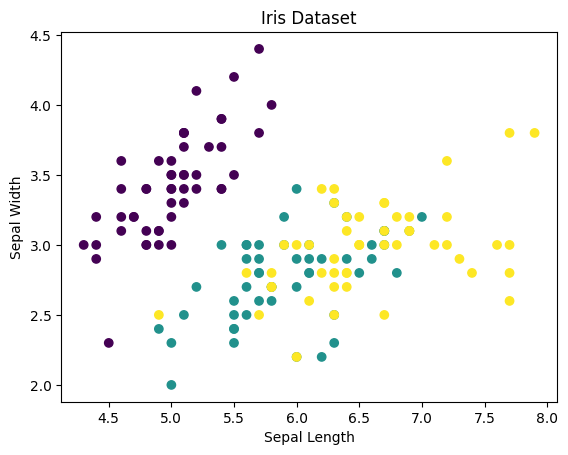

In [78]:
#visualize the data to check gaussian distribution
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Iris Dataset')
plt.show()

In [79]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [80]:
y_pred = gnb.predict(X_test)

In [81]:
accuracy=accuracy_score(y_test, y_pred)
report=classification_report(y_test, y_pred)
conf_matrix=confusion_matrix(y_test, y_pred)
print(f'The confusion matrix is:\n{conf_matrix}')
print(f'The classification report is:\n{report}')
print(f'The accuracy is: {accuracy}')

The confusion matrix is:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
The classification report is:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

The accuracy is: 1.0


### Bernoulli Naive Bayes

In [82]:
df = pd.read_excel('../data/bernoulli_nb_dataset.xlsx')
df.head()

,studied,attended_class,completed_assignments,practiced,passed
0,1,1,0,0,0
1,0,1,1,0,1
2,1,0,1,0,1
3,0,0,0,0,0
4,1,1,0,0,0


In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   studied                200 non-null    int64
 1   attended_class         200 non-null    int64
 2   completed_assignments  200 non-null    int64
 3   practiced              200 non-null    int64
 4   passed                 200 non-null    int64
dtypes: int64(5)
memory usage: 7.9 KB


In [84]:

#Split the data into features and target variable
X=df.drop('passed', axis=1)
y=df['passed']

In [85]:
#Seperate the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [86]:
model = BernoulliNB()
model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [87]:
y_pred = model.predict(X_test)

In [88]:
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
print(f'The confusion matrix is:\n{conf_matrix}')
print(f'The classification report is:\n{report}')
print(f'The accuracy is: {accuracy}')

The confusion matrix is:
[[14  2]
 [ 8 16]]
The classification report is:
              precision    recall  f1-score   support

           0       0.64      0.88      0.74        16
           1       0.89      0.67      0.76        24

    accuracy                           0.75        40
   macro avg       0.76      0.77      0.75        40
weighted avg       0.79      0.75      0.75        40

The accuracy is: 0.75


### Categorical Naive Bayes